# Task 7: Building the Code

Notebook-only implementation of the Task 7 PDF for a two-stage deep learning pipeline that reconstructs binary shapes from boundary measurements.

## Initialization

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

root = Path.cwd()
while root != root.parent and not (root / 'src').exists():
    root = root.parent
if str(root / 'src') not in sys.path:
    sys.path.insert(0, str(root / 'src'))

from models import (
    Stage1Regressor,
    Stage2MaskPredictor,
    evaluate_regression_predictions,
    evaluate_stage2_predictions,
    fit_stage1_model,
    fit_stage2_model,
    predict_tensor,
    set_torch_seed,
)
from measurements import (
    compute_gradient_data,
    GridSpec,
    add_gaussian_noise,
    coefficients_to_feature_vector,
    coefficients_to_measurements,
    compute_coefficients,
    create_grid,
    measurements_to_feature_vector,
)
from shapes import AnnulusSpec, CircleSpec, EllipseSpec, RectangleSpec, TwoCirclesSpec

rng = np.random.default_rng(42)
set_torch_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resultsFolder = Path("outputs/task7/Two_Stages")
resultsFolder.mkdir(parents=True, exist_ok=True)
print("Results folder:", resultsFolder.resolve())
print("Using device:", device)

Results folder: C:\Users\prest\Documents\minimal-gravimetry-ml\notebooks\task7\outputs\task7\Two_Stages
Using device: cuda


## Parameter Arrays

In [2]:
N_values = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
training_sizes = [2000, 4000, 6000, 8000, 10000, 20000, 40000, 80000, 160000, 320000]
validation_sizes = [500, 800, 1200, 1600, 2000, 4000, 8000, 16000, 32000, 64000]

meanIoU_perN = np.zeros(len(N_values), dtype=float)
overfitMetrics = []
allRunSummaries = []

## Data Generation Functions

In [3]:
def createFixedTestShapes():
    shapes = [
        EllipseSpec(a=0.6, b=0.3, theta=np.pi / 4.0, center=(0.1, 0.1)),
        CircleSpec(radius=0.5, center=(-0.1, -0.1)),
        AnnulusSpec(outer_radius=0.7, inner_radius=0.3, center=(0.0, 0.0)),
        RectangleSpec(width=0.8, height=0.4, theta=np.pi / 6.0, center=(0.2, -0.1)),
        TwoCirclesSpec(radius1=0.3, center1=(-0.4, 0.3), radius2=0.25, center2=(0.4, -0.2)),
    ]
    names = [
        "Ellipse (a=0.6, b=0.3, theta=45)",
        "Circle (radius=0.5)",
        "Annulus (R=0.7, r=0.3)",
        "Rectangle (0.8 x 0.4, theta=30)",
        "Two Disconnected Circles",
    ]
    return shapes, names


def random_center(rng_local, scale):
    values = (2.0 * rng_local.random(2) - 1.0) * scale
    return tuple(values.tolist())


def generateEllipse(rho, rng_local):
    return EllipseSpec(
        a=float(rng_local.uniform(0.2, 0.8)),
        b=float(rng_local.uniform(0.1, 0.6)),
        theta=float(rng_local.uniform(0.0, np.pi)),
        center=random_center(rng_local, rho * 0.8),
    )


def generateAnnulus(rho, rng_local):
    outer_radius = float(rng_local.uniform(0.3, 0.8))
    inner_radius = float(rng_local.uniform(0.05, 0.4))
    if inner_radius >= outer_radius:
        inner_radius = outer_radius * 0.5
    return AnnulusSpec(
        outer_radius=outer_radius,
        inner_radius=inner_radius,
        center=random_center(rng_local, rho * 0.6),
    )


def generateRectangle(rho, rng_local):
    return RectangleSpec(
        width=float(rng_local.uniform(0.2, 0.9)),
        height=float(rng_local.uniform(0.2, 0.7)),
        theta=float(rng_local.uniform(0.0, np.pi)),
        center=random_center(rng_local, rho * 0.8),
    )


def generateTwoCircles(rho, rng_local):
    return TwoCirclesSpec(
        radius1=float(rng_local.uniform(0.1, 0.35)),
        center1=random_center(rng_local, rho * 0.8),
        radius2=float(rng_local.uniform(0.1, 0.35)),
        center2=random_center(rng_local, rho * 0.8),
    )


def sample_task7_shape(config, rng_local):
    if config["N"] >= 6:
        prob_two_circles = 0.45
        prob_annulus = 0.10
        prob_rectangle = 0.25
        prob_ellipse = 0.15
    else:
        prob_two_circles = 0.45
        prob_annulus = 0.10
        prob_rectangle = 0.20
        prob_ellipse = 0.15

    draw = float(rng_local.random())
    if draw < prob_two_circles:
        return generateTwoCircles(config["rho"], rng_local)
    if draw < prob_two_circles + prob_annulus:
        return generateAnnulus(config["rho"], rng_local)
    if draw < prob_two_circles + prob_annulus + prob_rectangle:
        return generateRectangle(config["rho"], rng_local)
    if draw < prob_two_circles + prob_annulus + prob_rectangle + prob_ellipse:
        return generateEllipse(config["rho"], rng_local)
    return CircleSpec(radius=0.5, center=random_center(rng_local, 0.8))


def build_split(sample_count, config, grid, measurement_matrix, rng_local, fixed_shapes=None, fixed_names=None):
    gradient_data = []
    coefficients = []
    masks = []
    names = []

    if fixed_shapes is None:
        shape_entries = [(None, sample_task7_shape(config, rng_local)) for _ in range(sample_count)]
    else:
        shape_entries = list(zip(fixed_names, fixed_shapes))

    for display_name, shape in shape_entries:
        mask = shape.compute_mask(grid.X, grid.Y)
        coeff = compute_coefficients(mask, grid.X, grid.Y, grid.dA, n_max=config["N"]).coefficients
        gradient = compute_gradient_data(coeff, config["measurePoints"], config["N"])
        noisy_gradient = add_gaussian_noise(gradient, config["noiseLevel"], rng_local)

        gradient_data.append(measurements_to_feature_vector(noisy_gradient))
        coefficients.append(coefficients_to_feature_vector(coeff))
        masks.append(mask.astype(np.float32).reshape(-1))
        names.append(display_name or shape.type)

    return {
        "gradient_data": np.stack(gradient_data).astype(np.float32),
        "coefficients": np.stack(coefficients).astype(np.float32),
        "masks": np.stack(masks).astype(np.float32),
        "names": names,
    }


def save_fixed_shape_gallery(masks, names, grid_size, output_path):
    fig, axes = plt.subplots(1, len(names), figsize=(15, 3))
    for axis, name, mask in zip(axes, names, masks, strict=False):
        axis.imshow(mask.reshape(grid_size, grid_size), cmap="gray", origin="lower")
        axis.set_title(name)
        axis.axis("off")
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def save_fixed_reconstructions(true_masks, predicted_logits, names, grid_size, threshold, output_path):
    probabilities = 1.0 / (1.0 + np.exp(-predicted_logits))
    binary_masks = probabilities >= threshold
    fig, axes = plt.subplots(2, len(names), figsize=(15, 6))
    for idx, name in enumerate(names):
        axes[0, idx].imshow(true_masks[idx].reshape(grid_size, grid_size), cmap="gray", origin="lower")
        axes[0, idx].set_title(name)
        axes[0, idx].axis("off")
        axes[1, idx].imshow(binary_masks[idx].reshape(grid_size, grid_size), cmap="gray", origin="lower")
        axes[1, idx].axis("off")
    axes[0, 0].set_ylabel("True")
    axes[1, 0].set_ylabel("Pred")
    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

## Main Loop

In [4]:
for k, n_value in enumerate(N_values):
    config = {
        "N": n_value,
        "rho": 0.8,
        "gridSize": 32,
        "numMeasurePoints": n_value + 1,
        "trainingSamples": training_sizes[k],
        "validationSamples": validation_sizes[k],
        "testSamples": 500,
        "threshold": 0.5,
        "noiseType": "gaussian",
        "noiseLevel": 0.01,
        "batchSize": 64,
        "stage1Epochs": 20,
        "stage2Epochs": 20,
        "learningRate": 1e-3,
    }

    theta = np.linspace(0.0, 2.0 * np.pi, config["numMeasurePoints"] + 1)[:-1]
    measure_points = np.exp(1j * theta)
    measurement_matrix = np.zeros((config["numMeasurePoints"], config["N"] + 1), dtype=np.complex128)

    for row in range(config["numMeasurePoints"]):
        for n_idx in range(config["N"] + 1):
            measurement_matrix[row, n_idx] = 2.0 * np.conj(measure_points[row]) ** (-n_idx - 1)

    cond_M = float(np.linalg.cond(measurement_matrix))
    print(f"Cond(M) for N={config['N']}: {cond_M:.3e}")

    grid = create_grid(GridSpec(grid_size=config["gridSize"]))
    fixed_shapes, fixed_shape_names = createFixedTestShapes()

    train_split = build_split(config["trainingSamples"], config, grid, measurement_matrix, rng)
    val_split = build_split(config["validationSamples"], config, grid, measurement_matrix, rng)
    test_split = build_split(config["testSamples"], config, grid, measurement_matrix, rng)
    fixed_split = build_split(
        len(fixed_shapes),
        config,
        grid,
        measurement_matrix,
        rng,
        fixed_shapes=fixed_shapes,
        fixed_names=fixed_shape_names,
    )

    stage1_model = Stage1Regressor(
        input_dim=2 * config["numMeasurePoints"],
        output_dim=2 * (config["N"] + 1),
        hidden_dims=(128, 256, 128),
        dropout_rates=(0.2, 0.2, 0.2),
    )
    stage1_result = fit_stage1_model(
        model=stage1_model,
        train_features=train_split["gradient_data"],
        train_targets=train_split["coefficients"],
        val_features=val_split["gradient_data"],
        val_targets=val_split["coefficients"],
        epochs=200,
        batch_size=32,
        learning_rate=0.0005,
        device=device,
        early_stopping_patience=10,
    )

    from models import predict_stage1_coefficients
    predicted_train_coefficients = predict_stage1_coefficients(stage1_model, train_split["gradient_data"], device=device, training_result=stage1_result)
    predicted_val_coefficients = predict_stage1_coefficients(stage1_model, val_split["gradient_data"], device=device, training_result=stage1_result)
    predicted_test_coefficients = predict_stage1_coefficients(stage1_model, test_split["gradient_data"], device=device, training_result=stage1_result)
    predicted_fixed_coefficients = predict_stage1_coefficients(stage1_model, fixed_split["gradient_data"], device=device, training_result=stage1_result)

    stage2_model = Stage2MaskPredictor(
        input_dim=2 * (config["N"] + 1),
        output_dim=config["gridSize"] * config["gridSize"],
        hidden_dims=(256, 256),
    )
    stage2_result = fit_stage2_model(
        model=stage2_model,
        train_features=predicted_train_coefficients,
        train_targets=train_split["masks"],
        val_features=predicted_val_coefficients,
        val_targets=val_split["masks"],
        epochs=config["stage2Epochs"],
        batch_size=config["batchSize"],
        learning_rate=config["learningRate"],
        device=device,
    )

    predicted_test_masks = predict_tensor(stage2_model, predicted_test_coefficients, device=device)
    predicted_fixed_masks = predict_tensor(stage2_model, predicted_fixed_coefficients, device=device)

    stage1_test_metrics = evaluate_regression_predictions(test_split["coefficients"], predicted_test_coefficients)
    stage1_fixed_metrics = evaluate_regression_predictions(fixed_split["coefficients"], predicted_fixed_coefficients)
    stage2_test_metrics = evaluate_stage2_predictions(test_split["masks"], predicted_test_masks, config["threshold"])
    stage2_fixed_metrics = evaluate_stage2_predictions(fixed_split["masks"], predicted_fixed_masks, config["threshold"])

    meanIoU_perN[k] = stage2_fixed_metrics["mean_iou"]
    overfitMetrics.append({
        "N": config["N"],
        "stage1_train_loss": float(stage1_result.history["train_loss"][-1]),
        "stage1_val_loss": float(stage1_result.history["val_loss"][-1]),
        "stage1_overfit_gap": float(stage1_result.history["val_loss"][-1] - stage1_result.history["train_loss"][-1]),
        "stage2_train_loss": float(stage2_result.history["train_loss"][-1]),
        "stage2_val_loss": float(stage2_result.history["val_loss"][-1]),
        "stage2_overfit_gap": float(stage2_result.history["val_loss"][-1] - stage2_result.history["train_loss"][-1]),
    })

    runFolder = resultsFolder / f"N_{config['N']}"
    runFolder.mkdir(parents=True, exist_ok=True)
    save_fixed_shape_gallery(fixed_split["masks"], fixed_shape_names, config["gridSize"], runFolder / "fixed_shapes.png")
    save_fixed_reconstructions(
        fixed_split["masks"],
        predicted_fixed_masks,
        fixed_shape_names,
        config["gridSize"],
        config["threshold"],
        runFolder / "fixed_reconstructions.png",
    )

    runSummary = {
        "config": {key: value for key, value in config.items()},
        "condition_number": cond_M,
        "stage1_test_metrics": stage1_test_metrics,
        "stage1_fixed_metrics": stage1_fixed_metrics,
        "stage2_test_metrics": stage2_test_metrics,
        "stage2_fixed_metrics": stage2_fixed_metrics,
        "stage1_history": stage1_result.history,
        "stage2_history": stage2_result.history,
    }
    with (runFolder / "summary.json").open("w", encoding="utf-8") as fh:
        json.dump(runSummary, fh, indent=2)

    allRunSummaries.append({
        "N": config["N"],
        "condition_number": cond_M,
        "fixed_mean_iou": stage2_fixed_metrics["mean_iou"],
        "test_mean_iou": stage2_test_metrics["mean_iou"],
    })

Cond(M) for N=2: 1.000e+00
Cond(M) for N=4: 1.000e+00
Cond(M) for N=6: 1.000e+00
Cond(M) for N=8: 1.000e+00
Cond(M) for N=10: 1.000e+00
Cond(M) for N=12: 1.000e+00
Cond(M) for N=14: 1.000e+00
Cond(M) for N=16: 1.000e+00


C:\Users\prest\Documents\minimal-gravimetry-ml\src\gravimetry_ml\models\metrics.py:34: RuntimeWarning: overflow encountered in exp
  probabilities = 1.0 / (1.0 + np.exp(-logits))


Cond(M) for N=18: 1.000e+00
Cond(M) for N=20: 1.000e+00


## Summary

In [5]:
summary = {
    "N_values": N_values,
    "training_sizes": training_sizes,
    "validation_sizes": validation_sizes,
    "meanIoU_perN": meanIoU_perN.tolist(),
    "overfitMetrics": overfitMetrics,
    "runs": allRunSummaries,
}

with (resultsFolder / "task7_summary.json").open("w", encoding="utf-8") as fh:
    json.dump(summary, fh, indent=2)

print("meanIoU_perN:", meanIoU_perN)
print("overfitMetrics entries:", len(overfitMetrics))
summary

meanIoU_perN: [0.40338142 0.4860569  0.48032275 0.45297509 0.4715831  0.51113333
 0.65600288 0.6812098  0.7185649  0.7208554 ]
overfitMetrics entries: 10


{'N_values': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
 'training_sizes': [2000,
  4000,
  6000,
  8000,
  10000,
  20000,
  40000,
  80000,
  160000,
  320000],
 'validation_sizes': [500,
  800,
  1200,
  1600,
  2000,
  4000,
  8000,
  16000,
  32000,
  64000],
 'meanIoU_perN': [0.40338142176092884,
  0.4860568985458576,
  0.48032275133766184,
  0.4529750883218475,
  0.4715831035497652,
  0.5111333259982884,
  0.6560028806943684,
  0.6812097971539565,
  0.718564897689342,
  0.7208553965030113],
 'overfitMetrics': [{'N': 2,
   'stage1_train_loss': 2.4676876630991273e-07,
   'stage1_val_loss': 2.4207173865420373e-07,
   'stage1_overfit_gap': -4.697027655709007e-09,
   'stage2_train_loss': 0.7096839863806963,
   'stage2_val_loss': 0.6825423762202263,
   'stage2_overfit_gap': -0.02714161016047001},
  {'N': 4,
   'stage1_train_loss': 1.8685502680234947e-07,
   'stage1_val_loss': 2.2518989777171765e-07,
   'stage1_overfit_gap': 3.833487096936818e-08,
   'stage2_train_loss': 0.4764936940064506,

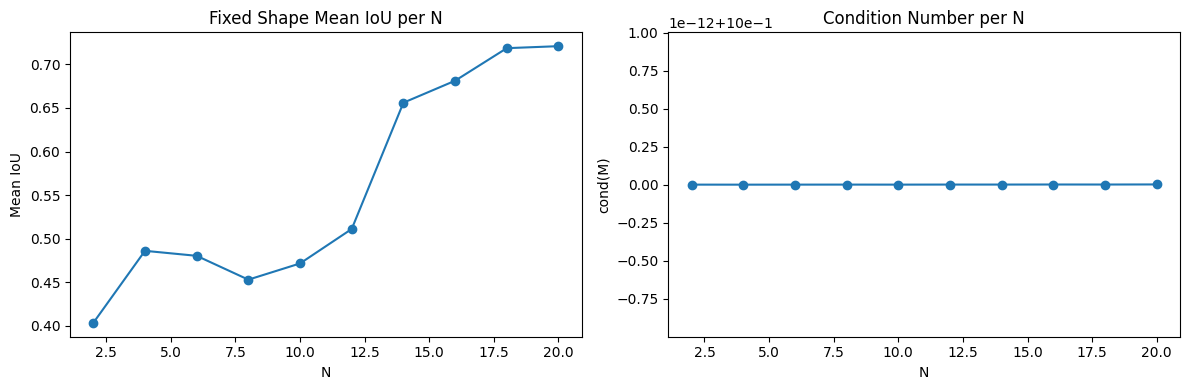

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(N_values, meanIoU_perN, marker="o")
axes[0].set_xlabel("N")
axes[0].set_ylabel("Mean IoU")
axes[0].set_title("Fixed Shape Mean IoU per N")

condition_numbers = [row["condition_number"] for row in allRunSummaries]
axes[1].plot(N_values, condition_numbers, marker="o")
axes[1].set_xlabel("N")
axes[1].set_ylabel("cond(M)")
axes[1].set_title("Condition Number per N")

fig.tight_layout()
fig.savefig(resultsFolder / "task7_overview.png", dpi=150, bbox_inches="tight")
plt.show()